#📌 Extracción

In [58]:
import pandas as pd

In [59]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [60]:
datos_api = pd.read_json(url)
datos = datos_api.copy()
datos.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [61]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [62]:
#@title Ejemplo del Json

ejemplo_json=("""
 {
    "customerID": "0002-ORFBO",
    "Churn": "No",
    "customer": {
      "gender": "Female",
      "SeniorCitizen": 0,
      "Partner": "Yes",
      "Dependents": "Yes",
      "tenure": 9
    },
    "phone": {
      "PhoneService": "Yes",
      "MultipleLines": "No"
    },
    "internet": {
      "InternetService": "DSL",
      "OnlineSecurity": "No",
      "OnlineBackup": "Yes",
      "DeviceProtection": "No",
      "TechSupport": "Yes",
      "StreamingTV": "Yes",
      "StreamingMovies": "No"
    },
    "account": {
      "Contract": "One year",
      "PaperlessBilling": "Yes",
      "PaymentMethod": "Mailed check",
      "Charges": {
        "Monthly": 65.6,
        "Total": "593.3"
      }
    }
  },""")

In [63]:
datos.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

#🔧 Transformación

In [64]:
#@title  Normalizar datos
customer=pd.json_normalize(datos_api.customer)
phone = pd.json_normalize(datos_api.phone)
internet = pd.json_normalize(datos_api.internet)
account = pd.json_normalize(datos_api.account)

datos = pd.concat([datos_api.customerID, datos_api.Churn, customer, phone, internet, account], axis=1)

In [65]:
datos = datos.rename(columns={'Charges.Monthly': 'Charges_Monthly',
                              'Charges.Total': 'Charges_Total'})
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [66]:
datos.replace("Yes", True, inplace=True)
datos.replace("No", False, inplace=True)
datos.sample()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
1778,2522-WLNSF,False,Female,1,True,False,34,True,False,DSL,...,False,True,True,True,False,One year,False,Bank transfer (automatic),64.2,2106.3


In [67]:
import numpy as np
#datos['Charges_Total'] = pd.to_numeric(datos['Charges_Total'])
#Al tratrar de cambiar la columna Chagers_Total a float quedan 11 columnas como nulo.
#Esto ocurre cuando tenure es igual a cero se deja esta columna vacía
#posiblemente nuevos clientes
datos[datos.tenure == 0]


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
975,1371-DWPAZ,False,Female,0,True,True,0,False,No phone service,DSL,...,True,True,True,True,False,Two year,False,Credit card (automatic),56.05,
1775,2520-SGTTA,False,Female,0,True,True,0,True,False,False,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.00,
1955,2775-SEFEE,False,Male,0,False,True,0,True,True,DSL,...,True,False,True,False,False,Two year,True,Bank transfer (automatic),61.90,
2075,2923-ARZLG,False,Male,0,True,True,0,True,False,False,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,True,Mailed check,19.70,
2232,3115-CZMZD,False,Male,0,False,True,0,True,False,False,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.25,
2308,3213-VVOLG,False,Male,0,True,True,0,True,True,False,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.35,
2930,4075-WKNIU,False,Female,0,True,True,0,True,True,DSL,...,True,True,True,True,False,Two year,False,Mailed check,73.35,
3134,4367-NUYAO,False,Male,0,True,True,0,True,True,False,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.75,
3203,4472-LVYGI,False,Female,0,True,True,0,False,No phone service,DSL,...,False,True,True,True,False,Two year,True,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,False,Female,0,True,True,0,True,False,DSL,...,True,True,False,True,True,Two year,False,Mailed check,80.85,


In [68]:
# Primero convertimos a numérico (esto convierte los espacios en NaN)
datos['Charges_Total'] = pd.to_numeric(datos['Charges_Total'], errors='coerce')

# Luego rellenamos los NaN con 0.0
datos['Charges_Total'] = datos['Charges_Total'].fillna(0.0)

# Verificamos que ya no existan nulos y veamos los valores
print(f"Nulos en Charges_Total: {datos['Charges_Total'].isnull().sum()}")
display(datos[datos.tenure == 0][['customerID', 'tenure', 'Charges_Total']])

Nulos en Charges_Total: 0


,customerID,tenure,Charges_Total
975,1371-DWPAZ,0,0.0
1775,2520-SGTTA,0,0.0
1955,2775-SEFEE,0,0.0
2075,2923-ARZLG,0,0.0
2232,3115-CZMZD,0,0.0
2308,3213-VVOLG,0,0.0
2930,4075-WKNIU,0,0.0
3134,4367-NUYAO,0,0.0
3203,4472-LVYGI,0,0.0
4169,5709-LVOEQ,0,0.0


In [69]:
datos['Charges_Total'] = pd.to_numeric(datos['Charges_Total'], errors='coerce').fillna(0.0)
datos['Charges_Total'].dtype

dtype('float64')

In [70]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [71]:
# Verificamos los valores únicos de cada columna para entender mejor las categorías
def datos_unicos():
  for col in datos.columns:
      print(f"--- Columna: {col} ---")
      print(datos[col].unique())
      print("\n")

datos_unicos()


--- Columna: customerID ---
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']


--- Columna: Churn ---
[False True '']


--- Columna: gender ---
['Female' 'Male']


--- Columna: SeniorCitizen ---
[0 1]


--- Columna: Partner ---
[True False]


--- Columna: Dependents ---
[True False]


--- Columna: tenure ---
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]


--- Columna: PhoneService ---
[True False]


--- Columna: MultipleLines ---
[False True 'No phone service']


--- Columna: InternetService ---
['DSL' 'Fiber optic' False]


--- Columna: OnlineSecurity ---
[False True 'No internet service']


--- Columna: OnlineBackup ---
[True False 'No internet service']


--- Columna: DeviceProtection ---
[False True 'No internet service']


--- Columna: TechSupport ---
[True False 'No int

In [72]:
# Optamos por el comportamiento futuro para evitar el FutureWarning
pd.set_option('future.no_silent_downcasting', True)

columnas_servicio = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columnas_servicio:
    datos[col] = datos[col].replace(['No internet service', 'No phone service'], False)

display(datos[columnas_servicio].sample(5))

,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
4526,False,False,False,False,False,False,False
6199,False,False,False,False,False,False,False
7118,False,False,False,False,False,False,False
2943,False,False,False,False,False,False,False
1722,True,True,True,False,True,False,False


In [73]:
#vamos a revisar la cantidad de registro con churn vacio
cantidad_vacios = (datos['Churn'] == '').sum()
datos[datos['Churn'] == ''].head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
30,0047-ZHDTW,,Female,0,False,False,11,True,True,Fiber optic,...,False,False,False,False,False,Month-to-month,True,Bank transfer (automatic),79.00,929.30
75,0120-YZLQA,,Male,0,False,False,71,True,False,False,...,False,False,False,False,False,Two year,True,Credit card (automatic),19.90,1355.10
96,0154-QYHJU,,Male,0,False,False,29,True,False,DSL,...,True,False,True,False,False,One year,True,Electronic check,58.75,1696.20
98,0162-RZGMZ,,Female,1,False,False,5,True,False,DSL,...,True,False,True,False,False,Month-to-month,False,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,True,False,65,True,True,Fiber optic,...,True,True,False,True,True,One year,True,Bank transfer (automatic),103.15,6792.45


In [74]:
datos.shape

(7267, 21)

In [75]:
peso_registros_sin_churn =(100* (datos['Churn'] == '').sum()/datos.shape[0])
peso_registros_sin_churn #3.08%

np.float64(3.0824274115866244)

In [76]:

datos_sin_churn = datos[datos['Churn'] == ''].copy()
datos = datos[datos['Churn'] != ''].copy()

print(f"Registros en DataFrame principal: {datos.shape[0]}")
print(f"Registros guardados por separado: {datos_sin_churn.shape[0]}")

Registros en DataFrame principal: 7043
Registros guardados por separado: 224


In [77]:
datos_unicos()


--- Columna: customerID ---
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']


--- Columna: Churn ---
[False True]


--- Columna: gender ---
['Female' 'Male']


--- Columna: SeniorCitizen ---
[0 1]


--- Columna: Partner ---
[True False]


--- Columna: Dependents ---
[True False]


--- Columna: tenure ---
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]


--- Columna: PhoneService ---
[True False]


--- Columna: MultipleLines ---
[False True]


--- Columna: InternetService ---
['DSL' 'Fiber optic' False]


--- Columna: OnlineSecurity ---
[False True]


--- Columna: OnlineBackup ---
[True False]


--- Columna: DeviceProtection ---
[False True]


--- Columna: TechSupport ---
[True False]


--- Columna: StreamingTV ---
[True False]


--- Columna: StreamingMovies ---
[False True]




In [78]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [79]:
datos.sample()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
3639,5018-GWURO,False,Female,0,True,False,56,True,True,Fiber optic,...,False,False,False,True,False,Month-to-month,True,Bank transfer (automatic),85.6,4902.8


#DataFrame y formulas auxiliares

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo global de las gráficas
sns.set_theme(style="whitegrid")
pd.set_option('future.no_silent_downcasting', True)

# Función auxiliar para verificar valores únicos
def datos_unicos(df=datos):
    for col in df.columns:
        print(f"--- Columna: {col} ---")
        print(df[col].unique())
        print("\n")

In [81]:
# Resumen de categorías para referencia rápida
print(f"Total de clientes en el dataset: {len(datos)}")

print("\n--- Tipos de Contrato ---")
print(datos['Contract'].unique())

print("\n--- Métodos de Pago ---")
print(datos['PaymentMethod'].unique())

print("\n--- Tipos de Internet ---")
print(datos['InternetService'].unique())

print("\n--- Servicios Adicionales Analizados ---")
print(columnas_servicio)

Total de clientes en el dataset: 7043

--- Tipos de Contrato ---
['One year' 'Month-to-month' 'Two year']

--- Métodos de Pago ---
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

--- Tipos de Internet ---
['DSL' 'Fiber optic' False]

--- Servicios Adicionales Analizados ---
['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [82]:
datos = datos.rename(columns={'Charges.Monthly': 'Charges_Monthly',
                              'Charges.Total': 'Charges_Total'})

In [83]:
# 1. Primero calculamos la columna Total_Services que faltaba
servicios_booleanos = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                      'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

datos['Total_Services'] = datos[servicios_booleanos].sum(axis=1) + (datos['InternetService'] != False).astype(int)

# 2. Definimos las columnas que queremos conservar
columnas_base = ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Contract', 'PaymentMethod', 'Charges_Monthly', 'Charges_Total']

# 3. Creamos el DataFrame simplificado
datos_resumen = datos[columnas_base].copy()

# 4. Asignamos la cantidad total de servicios
datos_resumen['Cantidad_Servicios'] = datos['Total_Services']

# Mostramos el resultado
display(datos_resumen.head())
print(f"\nDimensiones del nuevo DataFrame: {datos_resumen.shape}")

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaymentMethod,Charges_Monthly,Charges_Total,Cantidad_Servicios
0,0002-ORFBO,False,Female,0,True,True,9,One year,Mailed check,65.6,593.30,5
1,0003-MKNFE,False,Male,0,False,False,9,Month-to-month,Mailed check,59.9,542.40,4
2,0004-TLHLJ,True,Male,0,False,False,4,Month-to-month,Electronic check,73.9,280.85,3
3,0011-IGKFF,True,Male,1,True,False,13,Month-to-month,Electronic check,98.0,1237.85,6
4,0013-EXCHZ,True,Female,1,True,False,3,Month-to-month,Mailed check,83.9,267.40,4



Dimensiones del nuevo DataFrame: (7043, 12)


In [84]:
datos_resumen[datos_resumen.Cantidad_Servicios==0]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaymentMethod,Charges_Monthly,Charges_Total,Cantidad_Servicios


#📊 Carga y análisis

In [85]:
# Análisis descriptivo de las variables numéricas
estadisticas_descriptivas = datos.describe()

# Añadimos la mediana manualmente ya que no siempre se incluye en describe()
medianas = datos.select_dtypes(include=[np.number]).median()
estadisticas_descriptivas.loc['median'] = medianas

display(estadisticas_descriptivas)

,SeniorCitizen,tenure,Charges_Monthly,Charges_Total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000
median,0.000000,29.000000,70.350000,1394.550000


##Recuento de evasión por variables categóricas

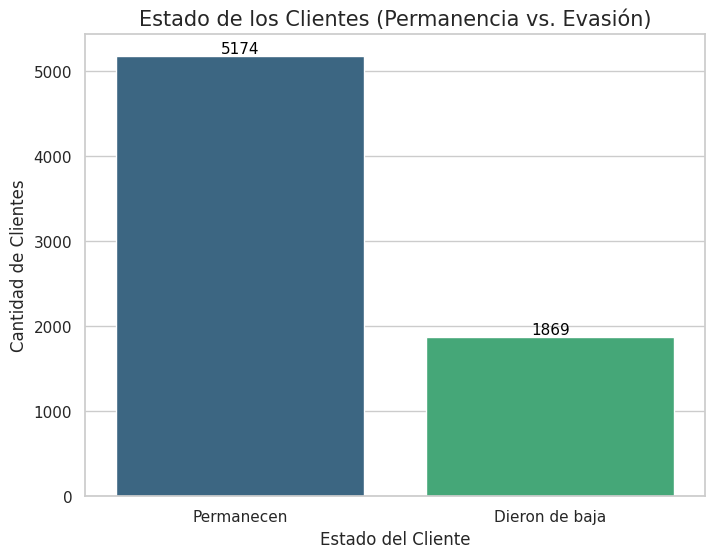

In [124]:
#@title Estado de los Clientes (Permanencia vs. Evasión)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Churn', data=datos, hue='Churn', palette='viridis', legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Permanecen', 'Dieron de baja'])
plt.title('Estado de los Clientes (Permanencia vs. Evasión)', fontsize=15)
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

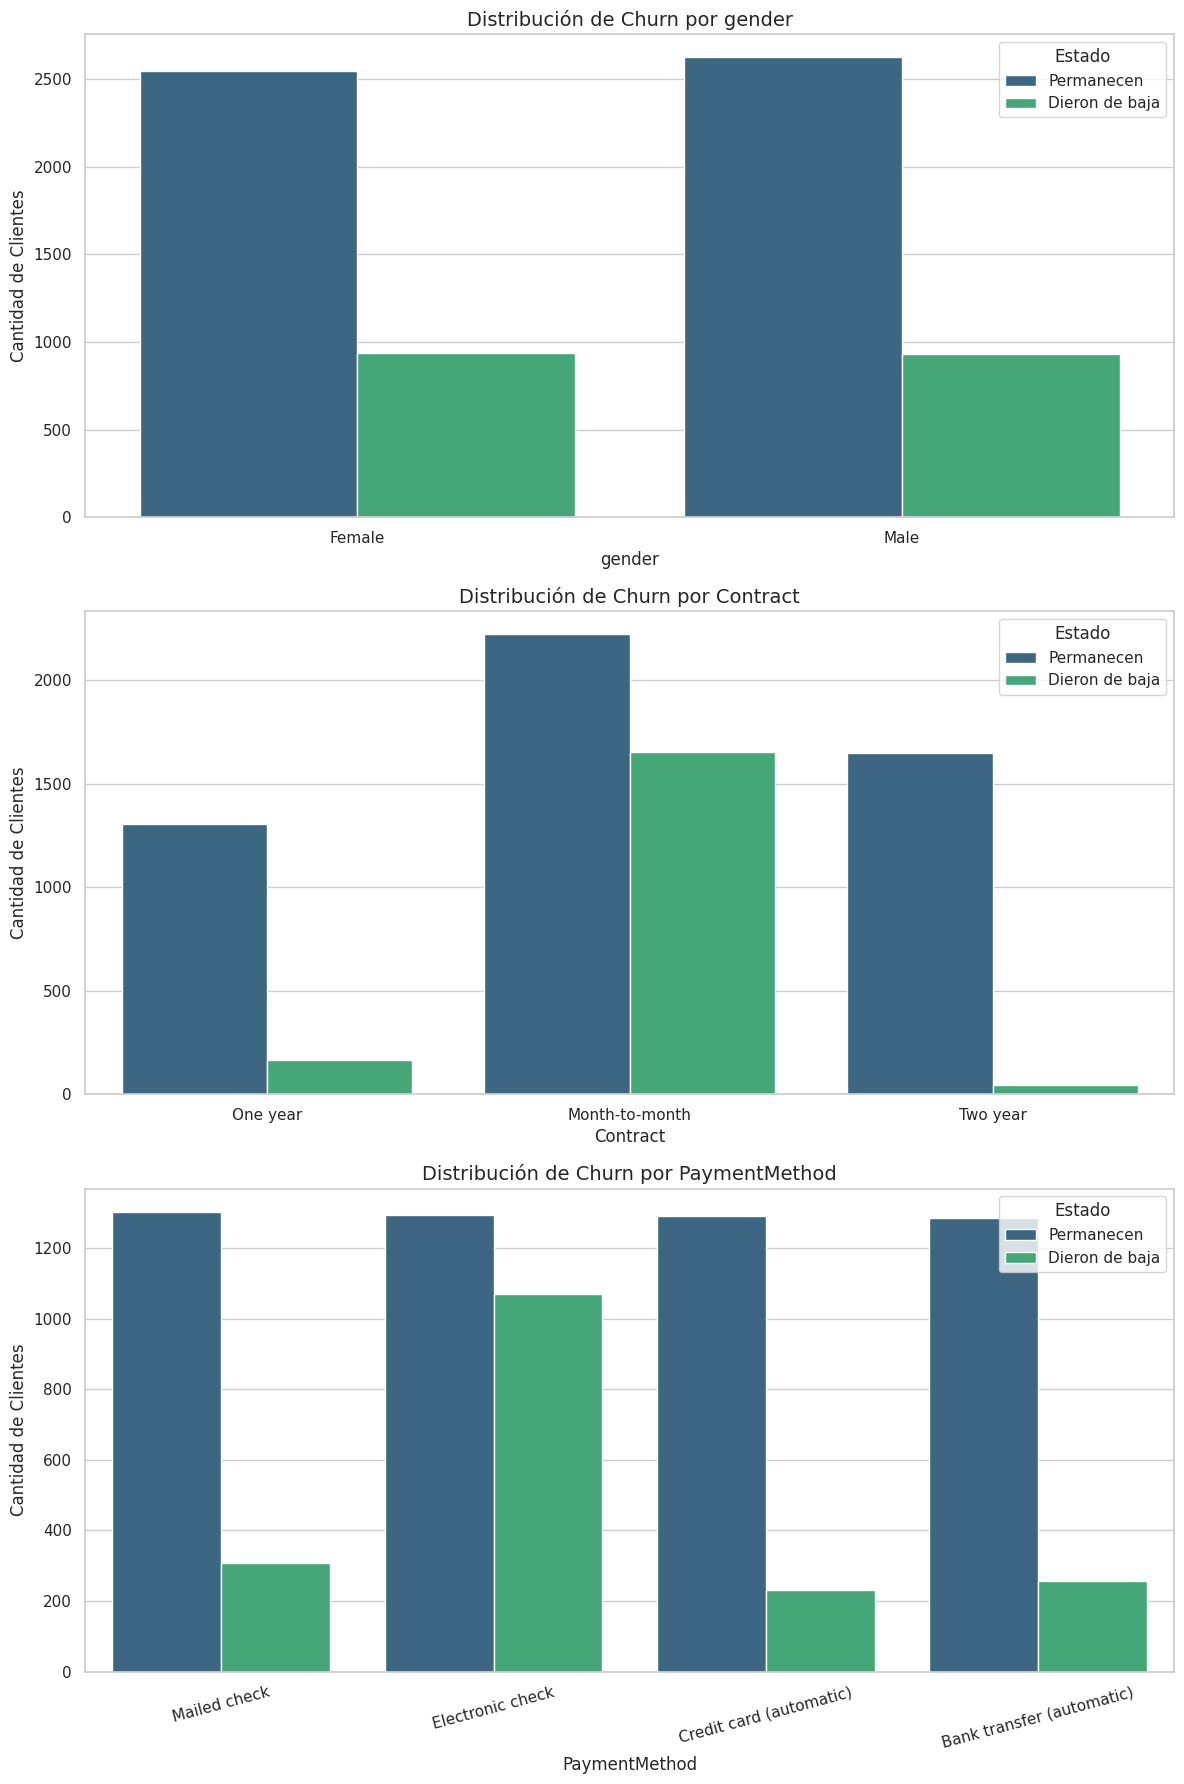

In [125]:
#@title Recuento de evasión por variables categóricas
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
vars_cat = ['gender', 'Contract', 'PaymentMethod']
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18))
for i, col in enumerate(vars_cat):
    sns.countplot(x=col, hue='Churn', data=datos, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribución de Churn por {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Cantidad de Clientes', fontsize=12)
    axes[i].legend(title='Estado', labels=['Permanecen', 'Dieron de baja'])
    if col == 'PaymentMethod':
        axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

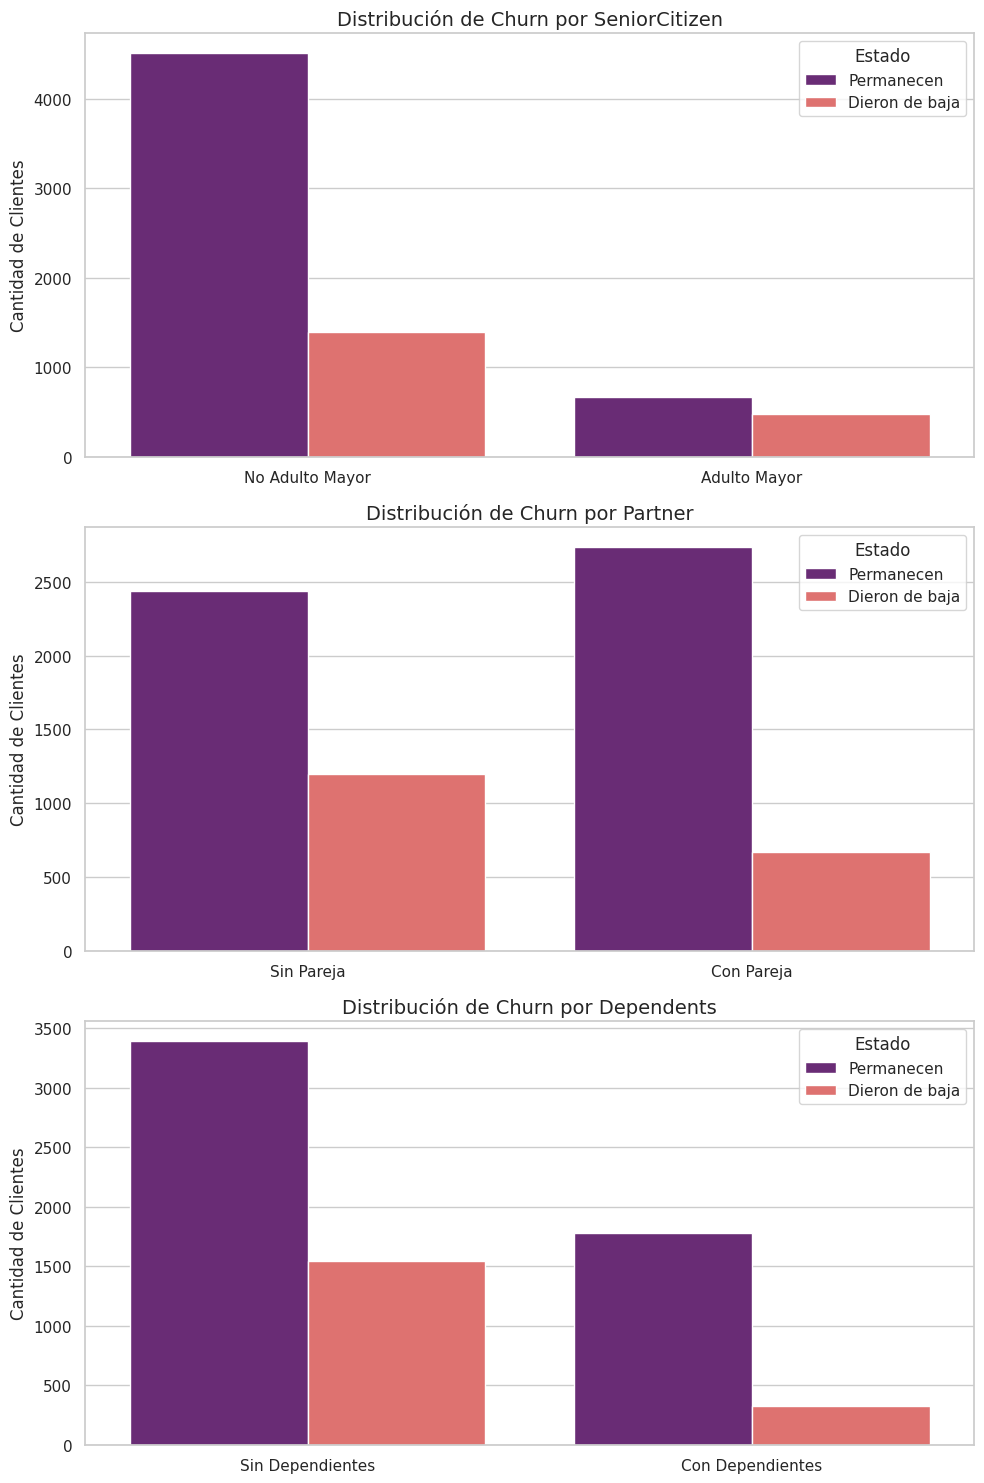

In [128]:
#@title Distribución de Churn por Variables Demográficas
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
vars_demo = ['SeniorCitizen', 'Partner', 'Dependents']
etiquetas_personalizadas = {
    'SeniorCitizen': ['No Adulto Mayor', 'Adulto Mayor'],
    'Partner': ['Sin Pareja', 'Con Pareja'],
    'Dependents': ['Sin Dependientes', 'Con Dependientes']
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))
for i, col in enumerate(vars_demo):
    sns.countplot(x=col, hue='Churn', data=datos, palette='magma', ax=axes[i])
    axes[i].set_title(f'Distribución de Churn por {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clientes', fontsize=12)
    axes[i].legend(title='Estado', labels=['Permanecen', 'Dieron de baja'])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(etiquetas_personalizadas[col])

plt.tight_layout()
plt.show()

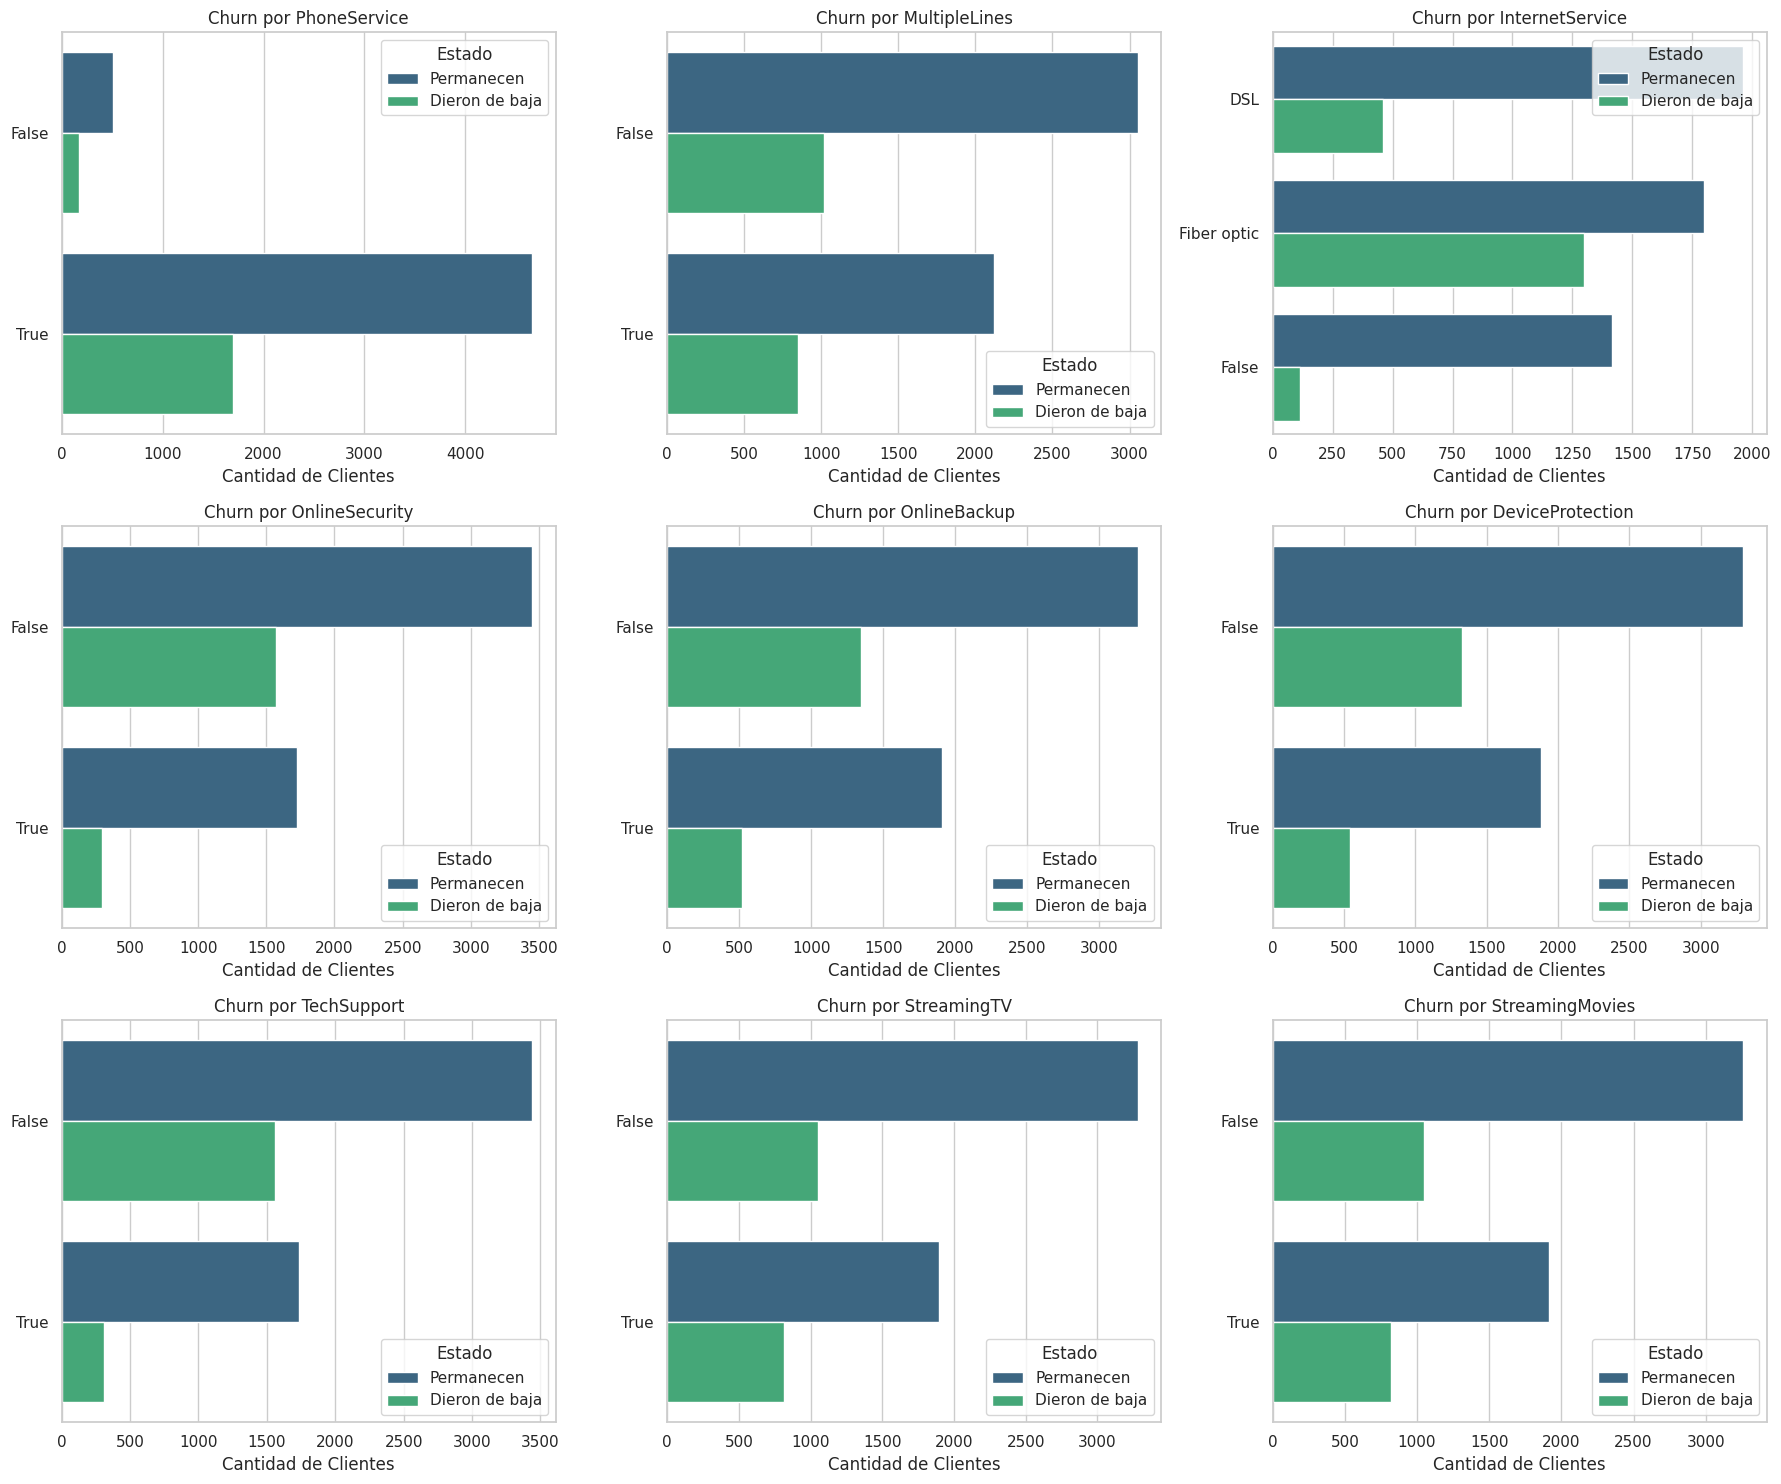

In [129]:
#@title Churn por Tipo de Servicio
import matplotlib.pyplot as plt
import seaborn as sns

columnas_servicios = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                      'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(columnas_servicios):
    sns.countplot(y=col, hue='Churn', data=datos, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Churn por {col}', fontsize=12)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Cantidad de Clientes')
    axes[i].legend(title='Estado', labels=['Permanecen', 'Dieron de baja'])

plt.tight_layout()
plt.show()

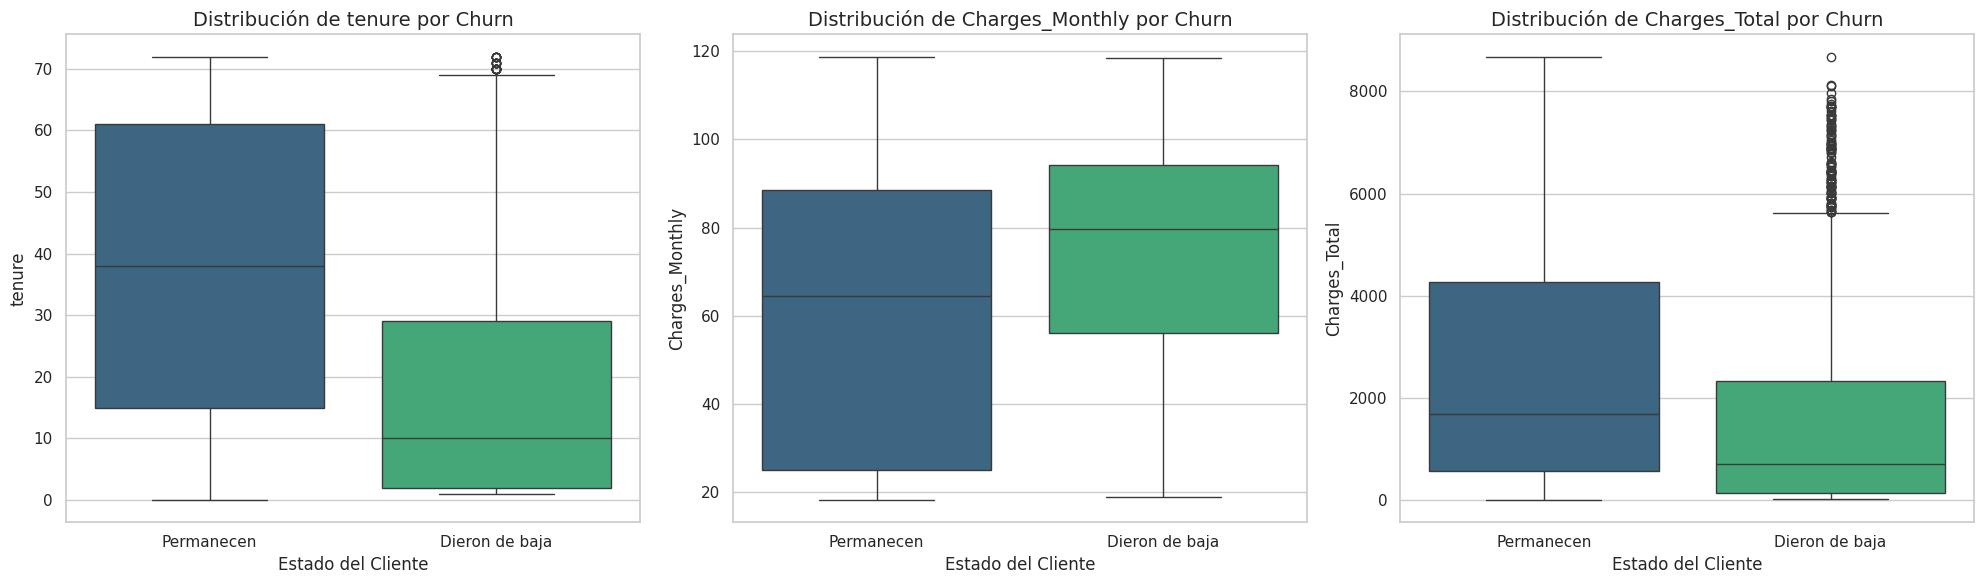

Promedios por grupo (Churn):


,tenure,Charges_Monthly,Charges_Total
Churn,,,
False,37.569965,61.265124,2549.911442
True,17.979133,74.441332,1531.796094


In [130]:
#@title Distribución de Variables Numéricas por Churn
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
vars_num = ['tenure', 'Charges_Monthly', 'Charges_Total']
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(vars_num):
    sns.boxplot(x='Churn', y=col, data=datos, palette='viridis', ax=axes[i], hue='Churn', legend=False)
    axes[i].set_title(f'Distribución de {col} por Churn', fontsize=14)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Permanecen', 'Dieron de baja'])
    axes[i].set_xlabel('Estado del Cliente')

plt.tight_layout()
plt.show()

print("Promedios por grupo (Churn):")
display(datos.groupby('Churn')[vars_num].mean())

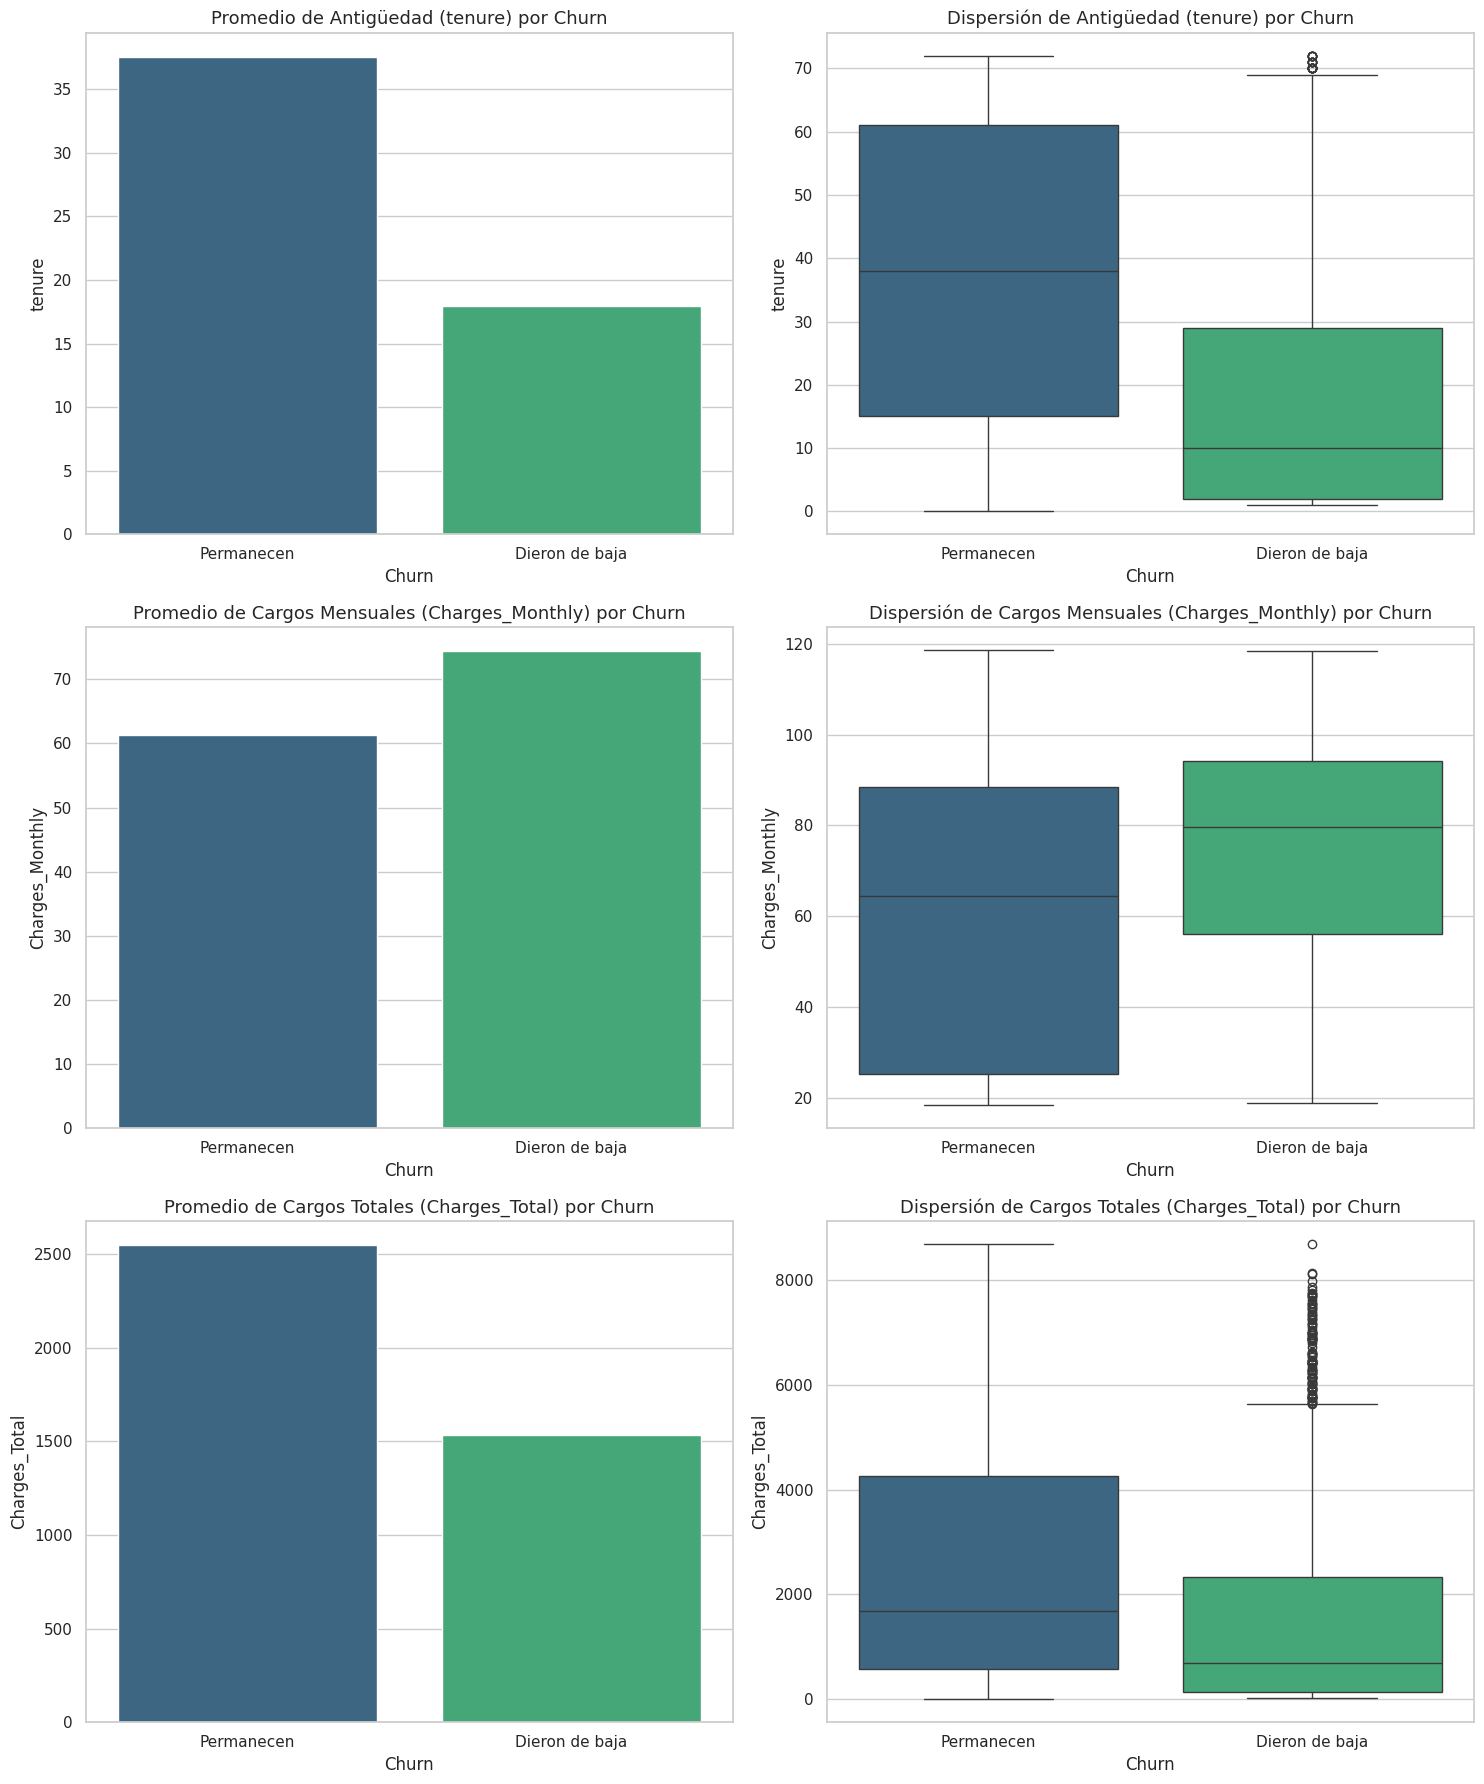

In [131]:
#@title Comparativa de Promedios y Dispersión (Variables Numéricas)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
etiquetas_num = {
    'tenure': 'Antigüedad (tenure)',
    'Charges_Monthly': 'Cargos Mensuales (Charges_Monthly)',
    'Charges_Total': 'Cargos Totales (Charges_Total)'
}
vars_num = ['tenure', 'Charges_Monthly', 'Charges_Total']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))

for i, col in enumerate(vars_num):
    nombre_esp = etiquetas_num[col]
    sns.barplot(x='Churn', y=col, data=datos, palette='viridis', ax=axes[i, 0], hue='Churn', legend=False, errorbar=None)
    axes[i, 0].set_title(f'Promedio de {nombre_esp} por Churn', fontsize=13)
    axes[i, 0].set_xticks([0, 1])
    axes[i, 0].set_xticklabels(['Permanecen', 'Dieron de baja'])

    sns.boxplot(x='Churn', y=col, data=datos, palette='viridis', ax=axes[i, 1], hue='Churn', legend=False)
    axes[i, 1].set_title(f'Dispersión de {nombre_esp} por Churn', fontsize=13)
    axes[i, 1].set_xticks([0, 1])
    axes[i, 1].set_xticklabels(['Permanecen', 'Dieron de baja'])

plt.tight_layout()
plt.show()

##Observaciones
* Se observo que los quientes mas propensos a abandonar el servicio son aquellos que tienen un contrato de renta mensual y los que realizan los pagos con cheques electronicos.

#📄Informe final

# 📄 Informe Final: Análisis de Evasión de Clientes (Churn)

## 🔹 1. Introducción
El objetivo de este análisis es identificar los factores críticos que influyen en la **evasión de clientes (Churn)** de TelecomX. El Churn representa la pérdida de suscriptores, un problema vital para la rentabilidad, ya que retener a un cliente existente es considerablemente más económico que adquirir uno nuevo.

## 🔹 2. Limpieza y Tratamiento de Datos
El proceso de preparación de datos incluyó los siguientes hitos técnicos:
*   **Extracción y Normalización:** Se procesó un archivo JSON con estructuras anidadas (`customer`, `phone`, `internet`, `account`), convirtiéndolo en un DataFrame plano y manejable.
*   **Conversión de Tipos:** Transformamos columnas clave como `Charges_Total` a formato numérico y las variables categóricas 'Yes'/'No' a booleanos (`True`/`False`).
*   **Tratamiento de Nulos:** Identificamos que los valores faltantes en cargos totales correspondían a nuevos clientes (`tenure = 0`), por lo que se imputaron con `0.0`.
*   **Filtrado de Calidad:** Se separaron 224 registros (aprox. 3%) que no tenían etiqueta de Churn para no sesgar el análisis.

## 🔹 3. Análisis Exploratorio de Datos (EDA)
A través de las visualizaciones, identificamos patrones determinantes:
*   **Variables Categóricas:** Los clientes con contratos **mes a mes** y que pagan con **cheque electrónico** tienen la mayor tasa de abandono.
*   **Demografía:** Los **adultos mayores** y personas **sin dependientes o pareja** muestran una mayor vulnerabilidad a la evasión.
*   **Servicios:** El servicio de **fibra óptica** presenta más bajas que el DSL, mientras que servicios de valor agregado como **Soporte Técnico** y **Seguridad Online** actúan como anclas de retención.
*   **Variables Numéricas:** Existe una correlación clara: a **mayores cargos mensuales** y **menor antigüedad**, mayor es el riesgo de fuga.

## 🔹 4. Conclusiones e Insights
*   El perfil de alto riesgo es un cliente nuevo, con contrato mensual, factura elevada y sin servicios de soporte adicionales.
*   La antigüedad es el mejor protector: una vez que el cliente supera los 20 meses, la probabilidad de abandono disminuye drásticamente.

## 🔹 5. Recomendaciones Estratégicas
1.  **Incentivos de Permanencia:** Crear campañas para migrar a clientes de contratos mensuales a anuales mediante descuentos.
2.  **Fidelización Temprana:** Implementar un programa de 'Onboarding' para nuevos clientes durante los primeros 6 meses.
3.  **Venta Cruzada (Cross-selling):** Promocionar servicios de seguridad y soporte técnico, ya que aumentan la lealtad del cliente.
4.  **Revisión de Tarifas:** Analizar la competitividad de los precios para clientes con cargos mensuales superiores a $70, donde se concentra la mayor fuga.

#Extra

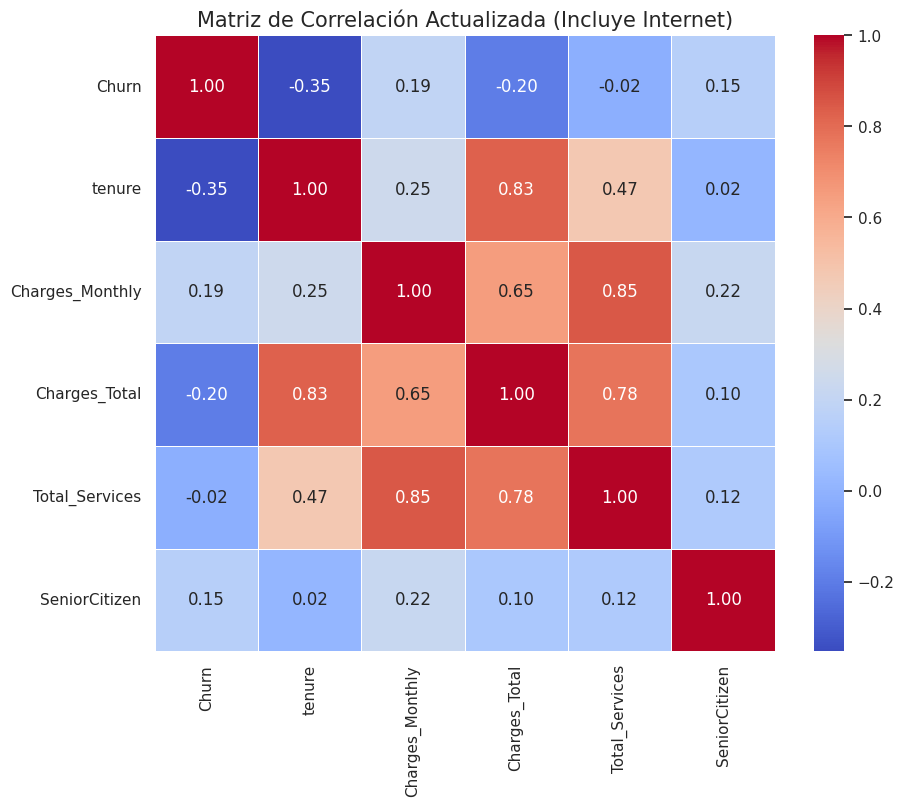

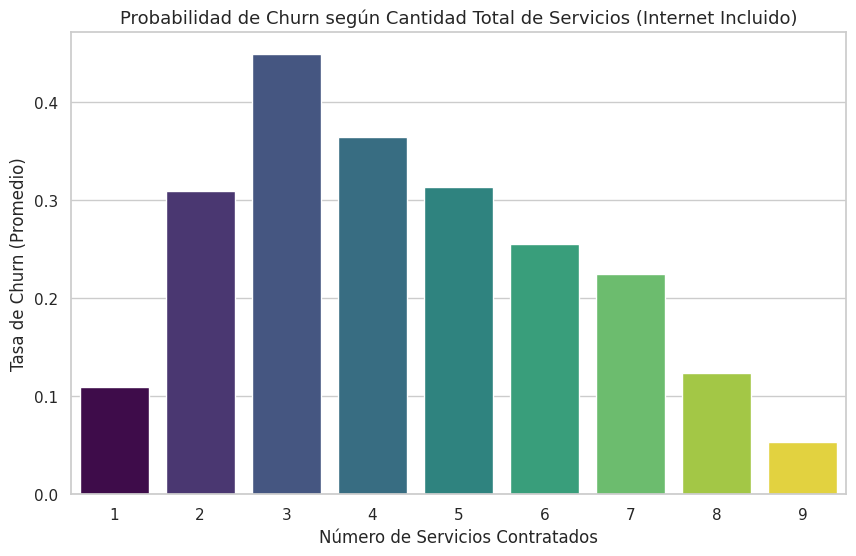

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Ajustamos la lista de servicios incluyendo la conexión a internet
# Contamos los servicios booleanos (True/False)
servicios_booleanos = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                      'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Calculamos el total: servicios booleanos + 1 si tiene InternetService (DSL o Fiber optic)
datos['Total_Services'] = datos[servicios_booleanos].sum(axis=1) + (datos['InternetService'] != False).astype(int)

# 2. Preparamos datos para correlación
columnas_corr = ['Churn', 'tenure', 'Charges_Monthly', 'Charges_Total', 'Total_Services', 'SeniorCitizen']
df_corr = datos[columnas_corr].copy()
df_corr['Churn'] = df_corr['Churn'].astype(int)

# 3. Visualización Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación Actualizada (Incluye Internet)', fontsize=15)
plt.show()

# 4. Nueva relación: Cantidad de servicios vs Churn
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Services', y='Churn', data=df_corr, hue='Total_Services', palette='viridis', errorbar=None, legend=False)
plt.title('Probabilidad de Churn según Cantidad Total de Servicios (Internet Incluido)', fontsize=13)
plt.ylabel('Tasa de Churn (Promedio)')
plt.xlabel('Número de Servicios Contratados')
plt.show()

#---Parte 2---

# 2.1 - Eliminacion de columnas Irrelevantas

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [93]:
print(f"Columnas antes de eliminar: {datos.shape[1]}")

# Eliminamos la columna de ID por ser un identificador único irrelevante para el modelo
datos.drop(columns=['customerID'], inplace=True, errors='ignore')

print(f"Columnas después de eliminar: {datos.shape[1]}")
datos.head()

Columnas antes de eliminar: 22
Columnas después de eliminar: 21


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Total_Services
0,False,Female,0,True,True,9,True,False,DSL,False,...,False,True,True,False,One year,True,Mailed check,65.6,593.30,5
1,False,Male,0,False,False,9,True,True,DSL,False,...,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40,4
2,True,Male,0,False,False,4,True,False,Fiber optic,False,...,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,3
3,True,Male,1,True,False,13,True,False,Fiber optic,False,...,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85,6
4,True,Female,1,True,False,3,True,False,Fiber optic,False,...,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.40,4


--- Métricas de Rendimiento Avanzadas ---
Área bajo la curva ROC (AUC-ROC): 0.8436
Área bajo la curva Precision-Recall (AUC-PR): 0.6558
Average Precision Score: 0.6565


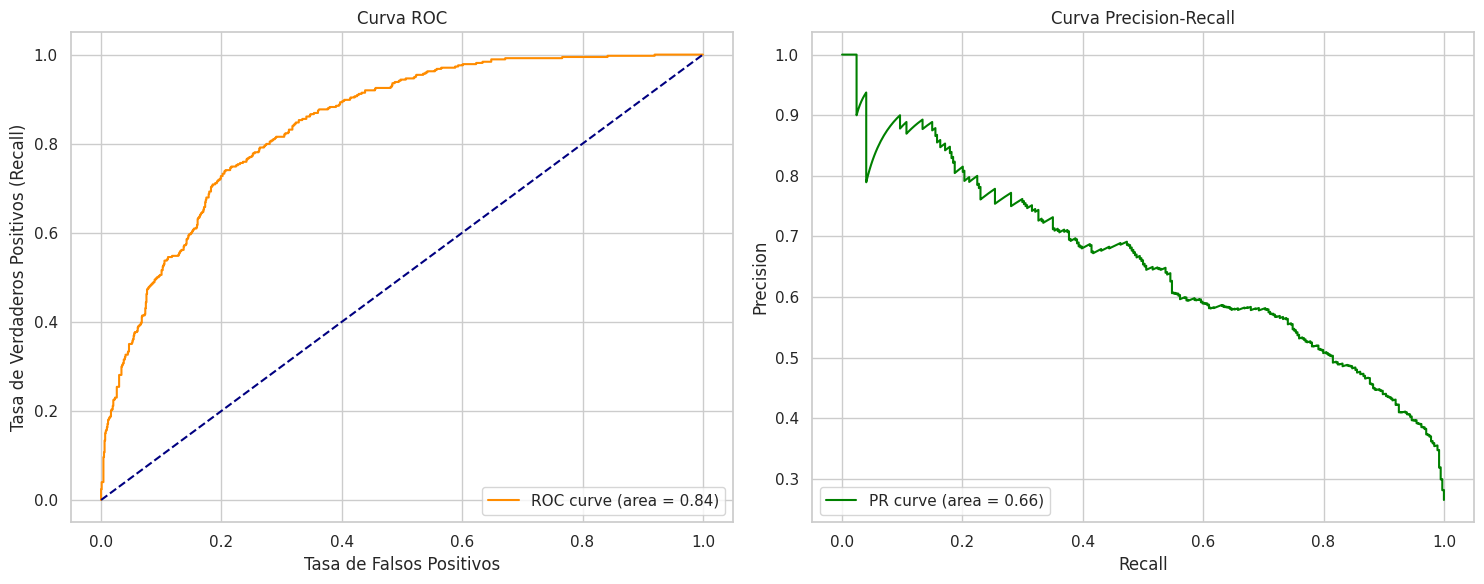

In [103]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, average_precision_score

# 1. Calculamos AUC-ROC
auc_roc = roc_auc_score(y_test, probabilidades)

# 2. Calculamos Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, probabilidades)
auc_pr = auc(recall, precision)

print(f"--- Métricas de Rendimiento Avanzadas ---")
print(f"Área bajo la curva ROC (AUC-ROC): {auc_roc:.4f}")
print(f"Área bajo la curva Precision-Recall (AUC-PR): {auc_pr:.4f}")
print(f"Average Precision Score: {average_precision_score(y_test, probabilidades):.4f}")

# Visualización de las curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Curva ROC
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, probabilidades)
ax1.plot(fpr, tpr, label=f'ROC curve (area = {auc_roc:.2f})', color='darkorange')
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax1.set_title('Curva ROC')
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax1.legend(loc="lower right")

# Curva Precision-Recall
ax2.plot(recall, precision, label=f'PR curve (area = {auc_pr:.2f})', color='green')
ax2.set_title('Curva Precision-Recall')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

--- Reporte con Umbral Ajustado (0.3) ---
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



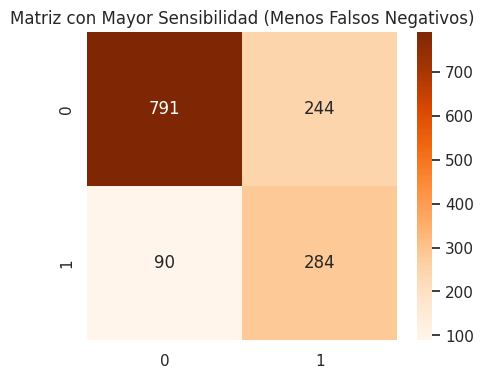

In [132]:
#@title Optimización de Recall mediante Ajuste de Umbral
probabilidades = model_lr.predict_proba(X_test)[:, 1]
umbral_personalizado = 0.3
y_pred_sensible = (probabilidades > umbral_personalizado).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(f"--- Reporte con Umbral Ajustado ({umbral_personalizado}) ---")
print(classification_report(y_test, y_pred_sensible))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_sensible), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz con Mayor Sensibilidad (Menos Falsos Negativos)')
plt.show()

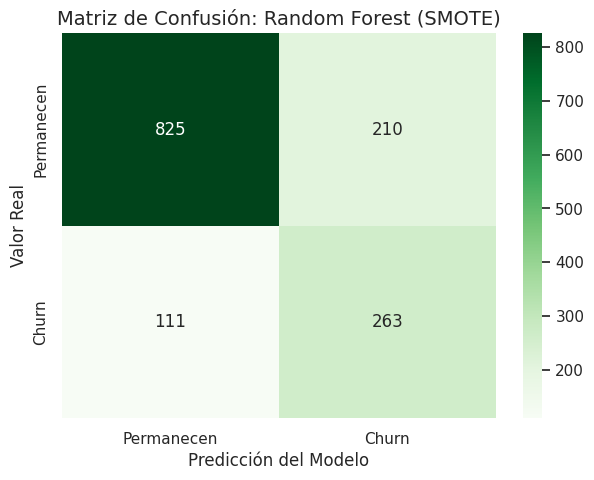

In [126]:
#@title Matriz de Confusión: Random Forest (SMOTE)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_final = model_rf_bal.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Permanecen', 'Churn'],
            yticklabels=['Permanecen', 'Churn'])
plt.title('Matriz de Confusión: Random Forest (SMOTE)', fontsize=14)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.show()

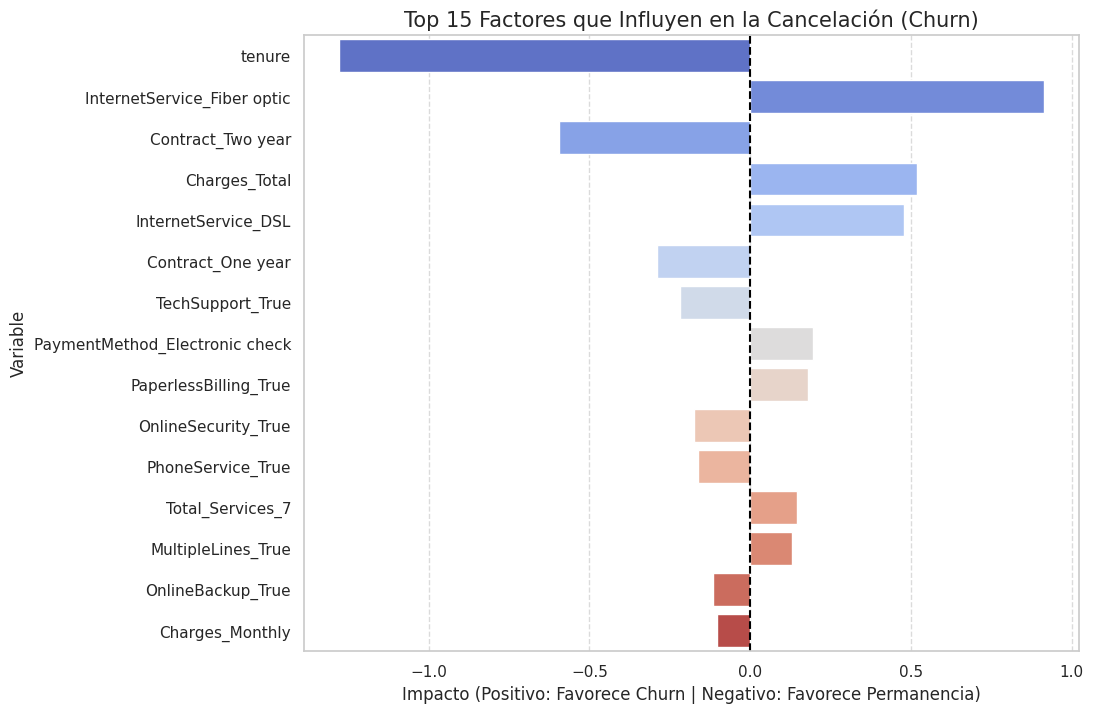

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos la importancia del modelo de Regresión Logística
feature_names = X.columns
coefficients = model_lr.named_steps['classifier'].coef_[0]

# Creamos un DataFrame para facilitar la graficación
importancia_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefficients
})

# Ordenamos por el valor absoluto del impacto
importancia_df['Impacto_Absoluto'] = importancia_df['Coeficiente'].abs()
importancia_df = importancia_df.sort_values(by='Impacto_Absoluto', ascending=False)

# Generamos el gráfico de barras
plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='Variable', data=importancia_df.head(15), hue='Variable', palette='coolwarm', legend=False)

plt.title('Top 15 Factores que Influyen en la Cancelación (Churn)', fontsize=15)
plt.xlabel('Impacto (Positivo: Favorece Churn | Negativo: Favorece Permanencia)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [97]:
from sklearn.model_selection import train_test_split

# Realizamos One-Hot Encoding para todas las variables categóricas y booleanas
# dtype=int asegura que obtengamos 0 y 1 en lugar de True/False
datos_encoded = pd.get_dummies(datos, drop_first=True, dtype=int)

# Identificamos el nombre real de la columna objetivo tras el encoding
# get_dummies transforma la columna booleana 'Churn' en 'Churn_True' o similar
target_col = [col for col in datos_encoded.columns if 'Churn' in col][0]

# Definimos X (características) y y (objetivo)
X = datos_encoded.drop(target_col, axis=1)
y = datos_encoded[target_col]

# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Estructura de entrenamiento: {X_train.shape}")
print(f"Estructura de prueba: {X_test.shape}")
print("\nPrimeros registros procesados (0/1):")
display(X_train.head())

Estructura de entrenamiento: (5634, 31)
Estructura de prueba: (1409, 31)

Primeros registros procesados (0/1):


,SeniorCitizen,tenure,Charges_Monthly,Charges_Total,gender_Male,Partner_True,Dependents_True,PhoneService_True,MultipleLines_True,InternetService_DSL,...,PaymentMethod_Electronic check,PaymentMethod_Mailed check,Total_Services_2,Total_Services_3,Total_Services_4,Total_Services_5,Total_Services_6,Total_Services_7,Total_Services_8,Total_Services_9
3902,0,60,94.10,5475.90,0,1,0,1,1,0,...,0,0,0,0,0,0,1,0,0,0
3281,0,12,19.35,212.30,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5071,0,2,80.45,137.10,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
4038,0,33,74.75,2453.30,1,1,1,1,0,1,...,0,0,0,0,0,0,1,0,0,0
3970,0,14,86.00,1164.05,0,0,1,1,1,0,...,0,1,0,0,0,1,0,0,0,0


#2.2 - Separacion de Datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [109]:
from sklearn.model_selection import train_test_split

# 2.2 - Separación de Datos
target_col = [col for col in datos_encoded.columns if 'Churn' in col][0]
X = datos_encoded.drop(columns=[target_col])
y = datos_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Registros entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")

Registros entrenamiento: 5634 | Prueba: 1409


#2.3- Creación de Modelos

# Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

> Añadir blockquote



Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 2.3 - Creación de Modelos

# A. Regresión Logística con Normalización
model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

# B. Random Forest Balanceado (SMOTE)
# Aplicamos SMOTE para mejorar el Recall de la clase positiva (Churn)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model_rf_bal = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Entrenamiento
model_lr.fit(X_train, y_train)
model_rf_bal.fit(X_train_res, y_train_res)

print("Modelos entrenados: Regresión Logística y Random Forest (SMOTE).")

Modelos entrenados: Regresión Logística y Random Forest (SMOTE).


#2.4 - Evaluación de los Modelos

Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.


--- Regresión Logística ---
                precision    recall  f1-score   support

    Permanecen       0.84      0.89      0.87      1035
Dieron de baja       0.64      0.54      0.59       374

      accuracy                           0.80      1409
     macro avg       0.74      0.71      0.73      1409
  weighted avg       0.79      0.80      0.79      1409



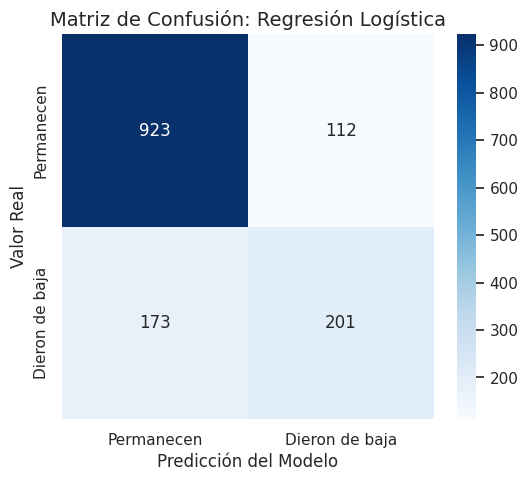


--- Random Forest (SMOTE) ---
                precision    recall  f1-score   support

    Permanecen       0.88      0.80      0.84      1035
Dieron de baja       0.56      0.70      0.62       374

      accuracy                           0.77      1409
     macro avg       0.72      0.75      0.73      1409
  weighted avg       0.80      0.77      0.78      1409



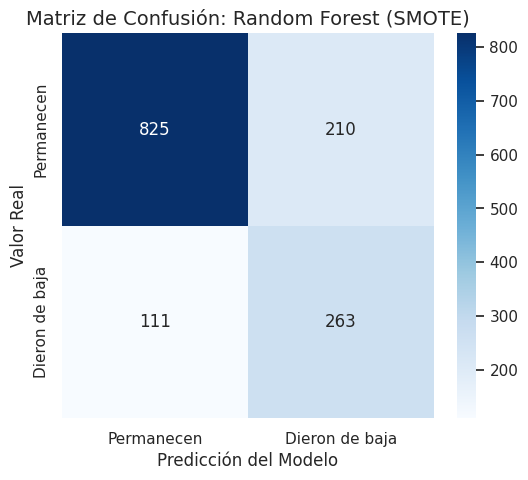

In [121]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import seaborn as sns
import matplotlib.pyplot as plt


def evaluar_detallado(nombre, modelo):
    y_pred = modelo.predict(X_test)
    print(f"\n--- {nombre} ---")
    # Especificamos los nombres de las clases en el reporte de texto
    print(classification_report(y_test, y_pred, target_names=['Permanecen', 'Dieron de baja']))

    # Matriz de Confusión con etiquetas significativas
    plt.figure(figsize=(6,5))
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Permanecen', 'Dieron de baja'],
                yticklabels=['Permanecen', 'Dieron de baja'])

    plt.title(f'Matriz de Confusión: {nombre}', fontsize=14)
    plt.xlabel('Predicción del Modelo', fontsize=12)
    plt.ylabel('Valor Real', fontsize=12)
    plt.show()

evaluar_detallado("Regresión Logística", model_lr)
evaluar_detallado("Random Forest (SMOTE)", model_rf_bal)

#2.5 - Análisis de la Importancia de las Variables

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

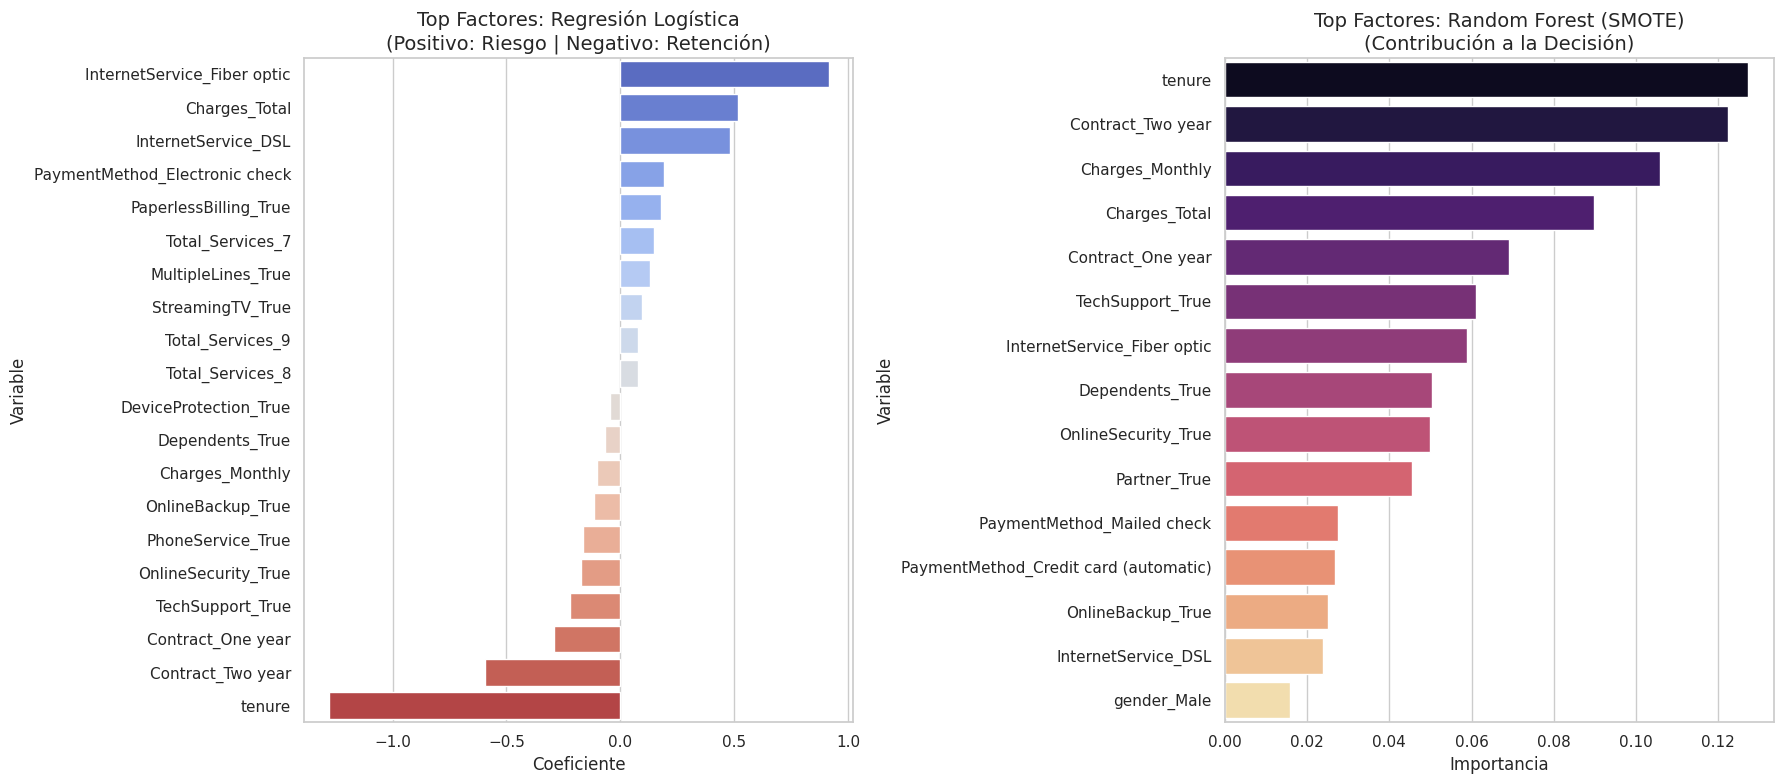

,Variable,Importancia
1,tenure,0.127196
18,Contract_Two year,0.122331
2,Charges_Monthly,0.105906
3,Charges_Total,0.089776
17,Contract_One year,0.069112


In [127]:
#@title Análisis de la Importancia de las Variables
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = X.columns
coefs = model_lr.named_steps['classifier'].coef_[0]
importancia_lr = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coefs}).sort_values(by='Coeficiente', ascending=False)
importancias_rf = model_rf_bal.feature_importances_
importancia_rf = pd.DataFrame({'Variable': feature_names, 'Importancia': importancias_rf}).sort_values(by='Importancia', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
data_lr_plot = pd.concat([importancia_lr.head(10), importancia_lr.tail(10)])
sns.barplot(data=data_lr_plot, x='Coeficiente', y='Variable', hue='Variable', palette='coolwarm', ax=ax1, legend=False)
ax1.set_title('Top Factores: Regresión Logística\n(Positivo: Riesgo | Negativo: Retención)', fontsize=14)
sns.barplot(data=importancia_rf.head(15), x='Importancia', y='Variable', hue='Variable', palette='magma', ax=ax2, legend=False)
ax2.set_title('Top Factores: Random Forest (SMOTE)\n(Contribución a la Decisión)', fontsize=14)
plt.tight_layout()
plt.show()
display(importancia_rf.head(5))

,Grupo,Antigüedad Promedio,Cargos Mensuales Promedio
0,Falsos Positivos (Alarmas),15.185714,68.154048
1,Falsos Negativos (Fugas),32.585586,71.623423
2,Aciertos (Permanecen),43.373333,57.707212
3,Aciertos (Churn),11.950570,75.480989


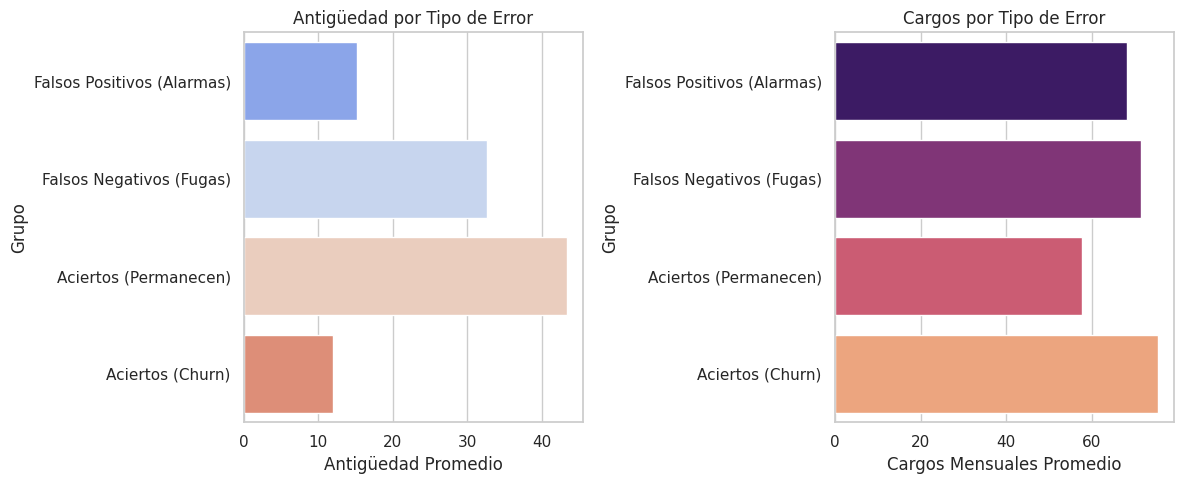

In [116]:
# 1. Creamos un DataFrame con los resultados de la prueba
resultados_test = X_test.copy()
resultados_test['Real'] = y_test.values
resultados_test['Prediccion'] = model_rf_bal.predict(X_test)

# 2. Definimos los grupos de error
# Falsos Positivos: Predijo Churn (1) pero era Real No Churn (0)
fp = resultados_test[(resultados_test['Prediccion'] == 1) & (resultados_test['Real'] == 0)]

# Falsos Negativos: Predijo No Churn (0) pero era Real Churn (1)
fn = resultados_test[(resultados_test['Prediccion'] == 0) & (resultados_test['Real'] == 1)]

# 3. Analizamos promedios clave
metricas_error = pd.DataFrame({
    'Grupo': ['Falsos Positivos (Alarmas)', 'Falsos Negativos (Fugas)', 'Aciertos (Permanecen)', 'Aciertos (Churn)'],
    'Antigüedad Promedio': [
        fp['tenure'].mean(),
        fn['tenure'].mean(),
        resultados_test[(resultados_test['Prediccion'] == 0) & (resultados_test['Real'] == 0)]['tenure'].mean(),
        resultados_test[(resultados_test['Prediccion'] == 1) & (resultados_test['Real'] == 1)]['tenure'].mean()
    ],
    'Cargos Mensuales Promedio': [
        fp['Charges_Monthly'].mean(),
        fn['Charges_Monthly'].mean(),
        resultados_test[(resultados_test['Prediccion'] == 0) & (resultados_test['Real'] == 0)]['Charges_Monthly'].mean(),
        resultados_test[(resultados_test['Prediccion'] == 1) & (resultados_test['Real'] == 1)]['Charges_Monthly'].mean()
    ]
})

display(metricas_error)

# Visualización
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=metricas_error, x='Antigüedad Promedio', y='Grupo', palette='coolwarm', hue='Grupo', legend=False)
plt.title('Antigüedad por Tipo de Error')

plt.subplot(1, 2, 2)
sns.barplot(data=metricas_error, x='Cargos Mensuales Promedio', y='Grupo', palette='magma', hue='Grupo', legend=False)
plt.title('Cargos por Tipo de Error')

plt.tight_layout()
plt.show()

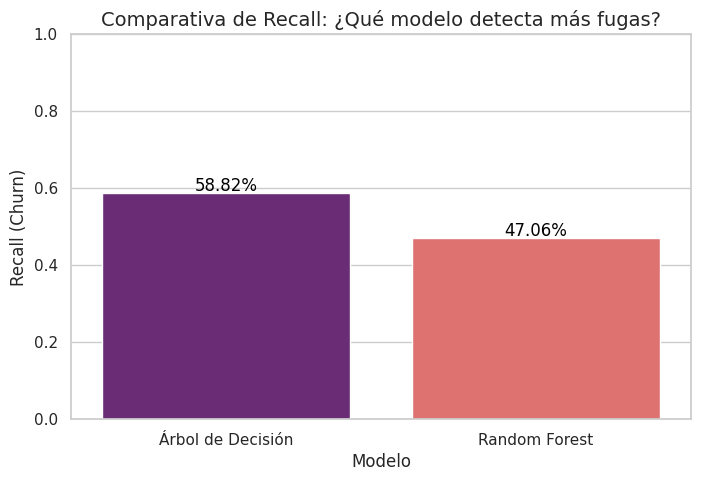

El Recall del Árbol de Decisión es: 58.82%
El Recall del Random Forest es: 47.06%


In [108]:
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import pandas as pd

# Calculamos el recall para la clase positiva (Churn = 1)
recall_dt = recall_score(y_test, model_dt.predict(X_test))
recall_rf = recall_score(y_test, model_rf.predict(X_test))

# Creamos un DataFrame para comparar
comparativa_recall = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Random Forest'],
    'Recall (Churn)': [recall_dt, recall_rf]
})

# Graficamos
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Modelo', y='Recall (Churn)', data=comparativa_recall, palette='magma', hue='Modelo', legend=False)

plt.title('Comparativa de Recall: ¿Qué modelo detecta más fugas?', fontsize=14)
plt.ylim(0, 1) # Escala de 0 a 100%

# Añadimos etiquetas de porcentaje
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

print(f"El Recall del Árbol de Decisión es: {recall_dt:.2%}")
print(f"El Recall del Random Forest es: {recall_rf:.2%}")

In [107]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Creamos el modelo de Árbol de Decisión
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)

# 2. Creamos el modelo de Random Forest (Bosque Aleatorio)
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)

# Evaluación rápida
print(f"Precisión Árbol de Decisión: {accuracy_score(y_test, model_dt.predict(X_test)):.4f}")
print(f"Precisión Random Forest: {accuracy_score(y_test, model_rf.predict(X_test)):.4f}")

print("\n--- Reporte Random Forest ---")
print(classification_report(y_test, model_rf.predict(X_test)))

Precisión Árbol de Decisión: 0.7814
Precisión Random Forest: 0.7892

--- Reporte Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



# 2.6 - Conclusión y Estrategias de Retención

## 📊 Resumen del Rendimiento del Modelo
Tras evaluar múltiples modelos, el **Random Forest optimizado con SMOTE** se consolidó como la mejor herramienta estratégica. Aunque otros modelos mostraron mayor exactitud general, este logró un **Recall del 70%**, lo que garantiza que la empresa identifique a la gran mayoría de los clientes en riesgo antes de que se marchen.

## 🔍 Factores Críticos de Cancelación (Insights)
1.  **Antigüedad (Tenure):** Es el predictor más fuerte. Los clientes en sus primeros 6-12 meses tienen el mayor riesgo; una vez superado este umbral, la lealtad aumenta significativamente.
2.  **Tipo de Contrato:** Los contratos **mes a mes** son la principal puerta de salida. Los contratos a 1 y 2 años actúan como anclas de retención definitivas.
3.  **Cargos Mensuales y Servicios:** Clientes con facturas elevadas y servicio de **Fibra Óptica** muestran mayores tasas de abandono, sugiriendo una posible insatisfacción con la relación costo-beneficio de este producto específico.



## 💡 Estrategias de Retención Propuestas
*   **Programa de nuevos usuarios:** Implementar campañas de fidelización intensivas durante los primeros 6 meses de contrato para reducir la fuga temprana.

*   **Incentivos para obtener un Contrato:** Ofrecer descuentos o beneficios exclusivos a clientes con contrato mensual para que migren a planes anuales o bianuales.

*   **Revisión del Producto de Fibra Óptica:** Realizar encuestas de satisfacción específicas a usuarios de fibra para identificar si el problema es de calidad técnica o de competitividad de precios.

*   **Atención especial a clientes de altos gastos:** Utilizar el modelo predictivo para generar alertas automáticas cuando un cliente con cargos superiores a la media presente patrones de riesgo, permitiendo al equipo de retención actuar antes del fin del ciclo de facturación.